### Mathematical Transformations for Normality

Linear machine learning models (like Linear Regression and Logistic Regression) assume that the numerical features are normally distributed. Applying mathematical transformations helps reshape the **Probability Density Function (PDF)** of skewed data into a normal distribution to achieve better model accuracy.

---

### Types of Transformers

#### 1. Function Transformer
Used for standard mathematical functions:
* **Log Transform:** $f(x) = \log(x)$ *(Great for right-skewed data; requires values $> 0$)*
* **Reciprocal Transform:** $f(x) = \frac{1}{x}$
* **Square Root Transform:** $f(x) = \sqrt{x}$
* **Custom Transform:** Any user-defined function.

#### 2. Power Transformer
More complex parametric `transformations used to stabilize variance and force normality:
* **Box-Cox:** Requires data to be strictly positive ($x > 0$).
* **Yeo-Johnson:** Works for both positive, zero, and negative data values.

---

### How to Check if Data is Normally Distributed

To determine if your feature requires a transformation, you can use these diagnostic tools:

#### A. Visualizing the Distribution
```python
sns.distplot(df['column_name']) 
# Note: In modern seaborn, use sns.histplot(df['column_name'], kde=True)
```
#### B. Skew Value
```python
df['column_name'].skew()
```
#### C. Quantile-Quantile Plot (Q-Q Plot) — Very Reliable

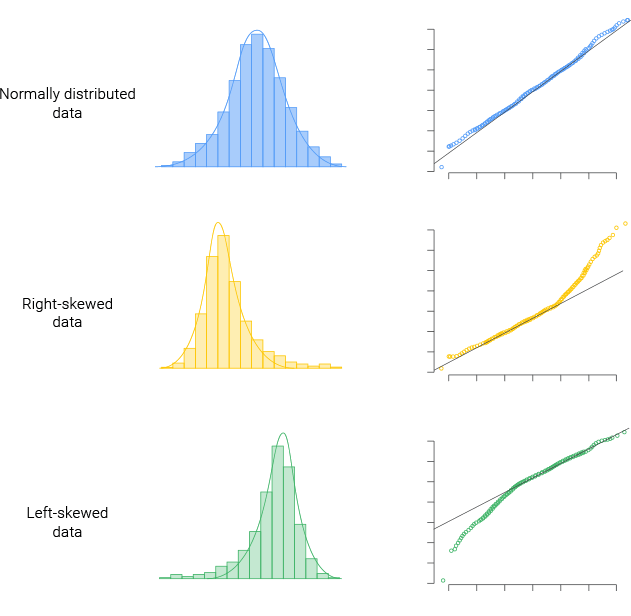

Log transform: take log of each value
not possible on -ve values
use on right skewed data

before:
1-10---------100------------------------------------------------------1000

after:
1--10--100--1000

### Log Transform

* **Mechanism:** Take log of each value.
* **Constraint:** Not possible on -ve values.
* **Use Case:** Use on right skewed data.

#### Visualizing the Scale Change

**Before:**
```text
1-10---------100------------------------------------------------------1000

```

**After:**

```text
1--10--100--1000

```


### Other Function Transformers

* **Reciprocal:** $\frac{1}{x}$ (Flips small values to large, and large values to small).
* **Square (sq):** $x^2$ (Used for left skewed data).
* **Square Root (sqrt):** $\sqrt{x}$ (Used for moderately right skewed data).

# START

In [64]:
import pandas as pd
import numpy as np

import scipy.stats as stats #For QQ plot

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.preprocessing import FunctionTransformer

from sklearn.compose import ColumnTransformer

In [65]:
df = pd.read_csv('../Data sets/titanic.csv', usecols=['Age','Fare','Survived'])

In [66]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [67]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

* instead of oding df = ...., we can do same thing by `inplace=True`

#### Train test split

In [68]:
X = df.iloc[:,1:3]
Y = df.iloc[:,0]

In [69]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

C:\Users\luqma\AppData\Local\Temp\ipykernel_25320\95924279.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


Text(0.5, 1.0, 'Age QQ')

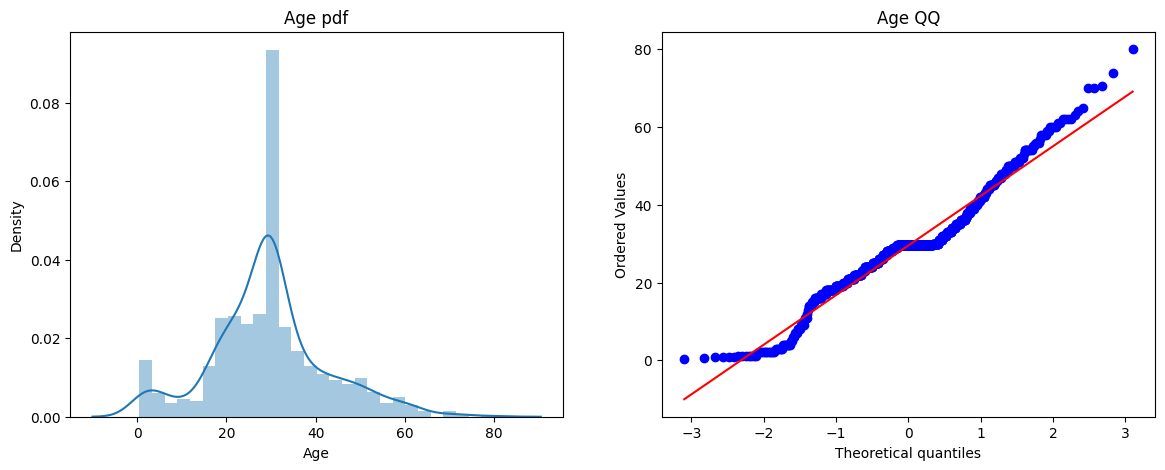

In [70]:
plt.figure(figsize=(14,5))

plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age pdf')


plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ')

C:\Users\luqma\AppData\Local\Temp\ipykernel_25320\2609998863.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


Text(0.5, 1.0, 'Fare QQ')

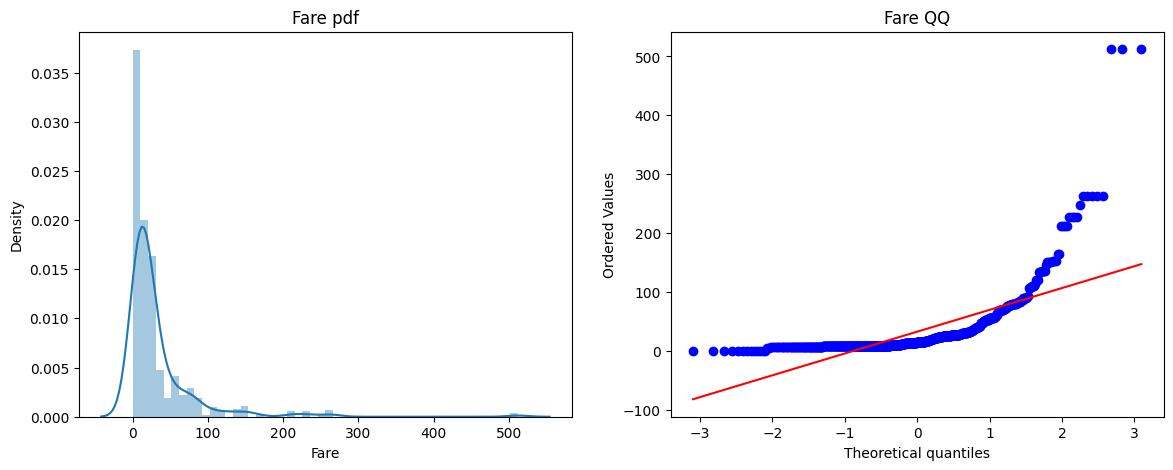

In [71]:
plt.figure(figsize=(14,5))

plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare pdf')


plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ')

#### This is right skewed: log transform

In [72]:
m1 = LogisticRegression()
m2 = DecisionTreeClassifier()

In [73]:
m1.fit(X_train,Y_train)
m2.fit(X_train,Y_train)

pred1 = m1.predict(X_test)
pred2 = m2.predict(X_test)

print(f'Linear: {accuracy_score(pred1,Y_test)*100:.2f}')
print(f'tree: {accuracy_score(pred2,Y_test)*100:.2f}')

Linear: 64.80
tree: 65.92


In [74]:
T = FunctionTransformer(np.log1p) #np.log1p is the log function u can use any function

X_train_transformed = T.fit_transform(X_train)
X_test_transformed = T.fit_transform(X_test)

we used log1p instead of log coz log(0) = undefined and log1p adds 1 to all 

In [75]:
m1 = LogisticRegression()
m2 = DecisionTreeClassifier()

m1.fit(X_train_transformed,Y_train)
m2.fit(X_train_transformed, Y_train)

pred1 = m1.predict(X_test_transformed)
pred2 = m2.predict(X_test_transformed)

print(f' Linear: {accuracy_score(pred1,Y_test)*100:.2f}')
print(f' Tree: {accuracy_score(pred2,Y_test)*100:.2f}')

 Linear: 68.16
 Tree: 65.92


Text(0.5, 1.0, 'Fare QQ after log')

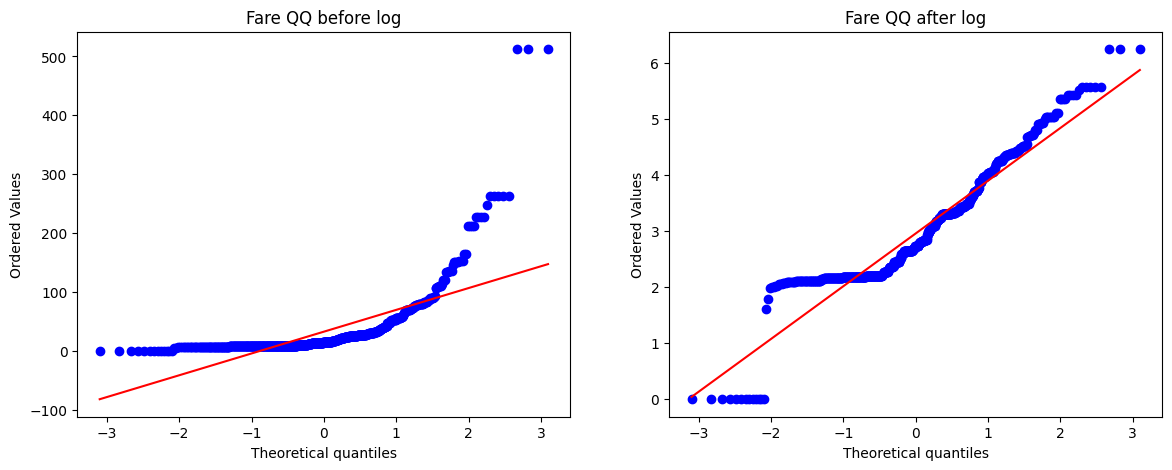

In [76]:
plt.figure(figsize=(14,5))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ before log')


plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ after log')

Text(0.5, 1.0, 'age after transformation')

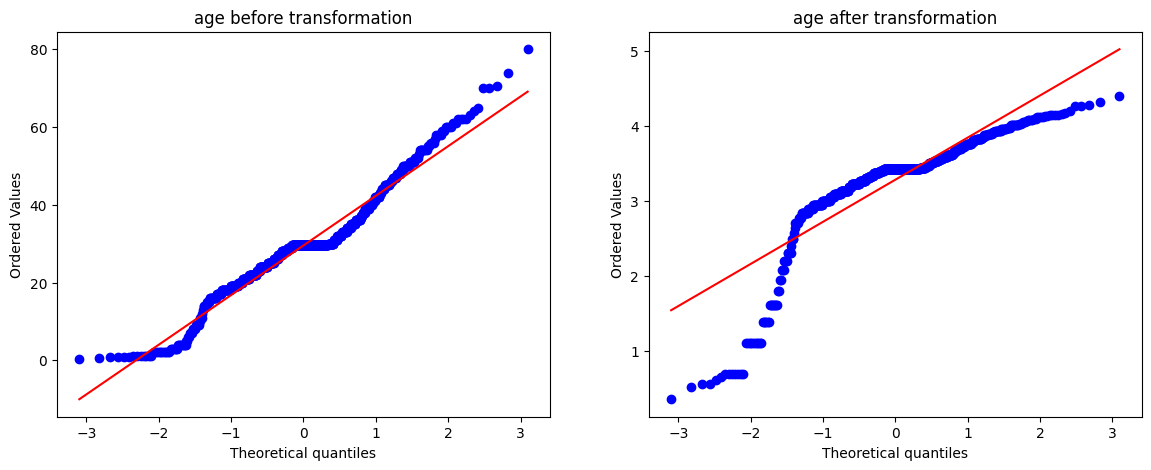

In [77]:
plt.figure(figsize=(14,5))

plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('age before transformation')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist='norm', plot=plt)
plt.title('age after transformation')

#### fare got better byt **Age got worst** after transformation!

so lets apply this only to fare it shld give better result

In [87]:
FT = ColumnTransformer([
    ('log',FunctionTransformer(np.log1p),['Fare'])
], remainder='passthrough')

X_train_transformed2 = FT.fit_transform(X_train)
X_test_transformed2 = FT.fit_transform(X_test)

In [88]:
m1.fit(X_train_transformed2,Y_train)
m2.fit(X_train_transformed2,Y_train)

pred1 = m1.predict(X_test_transformed2)
pred2 = m2.predict(X_test_transformed2)

print(f'{accuracy_score(pred1,Y_test)}')
print(f'{accuracy_score(pred2, Y_test)}')

0.6703910614525139
0.6759776536312849


In [ ]:
#### add any transformation to FunctionTransformer(), square is applied to right skewed data

In [99]:
FT = ColumnTransformer([
    ('log',FunctionTransformer(lambda x:x**3),['Fare'])
], remainder='passthrough')

X_train_transformed2 = FT.fit_transform(X_train)
X_test_transformed2 = FT.fit_transform(X_test)

m1.fit(X_train_transformed2,Y_train)
m2.fit(X_train_transformed2,Y_train)

pred1 = m1.predict(X_test_transformed2)
pred2 = m2.predict(X_test_transformed2)

print(f'{accuracy_score(pred1,Y_test)}')
print(f'{accuracy_score(pred2, Y_test)}')

0.5977653631284916
0.6871508379888268
